In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import mhnlib.utils as mhn_utils
from math import log, sqrt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
torch.cuda.empty_cache()

In [5]:
def random_fourier_manifold(num_samples : int, intrinsic_dim : int, extrinsic_dim : int, n_modes : int, nonlinear_scale : float, freq_scale : float):
    latent_coord = torch.randn(num_samples, intrinsic_dim)
    random_proj = torch.randn(intrinsic_dim, extrinsic_dim)
    x = latent_coord @ random_proj
    omega = freq_scale * torch.randn(n_modes, intrinsic_dim)
    b = (nonlinear_scale / sqrt(n_modes))*torch.randn(n_modes, extrinsic_dim)

    c = (nonlinear_scale / sqrt(n_modes))*torch.randn(n_modes, extrinsic_dim)

    phase = latent_coord @ omega.T

    x += torch.cos(phase) @ b
    x += torch.sin(phase) @ c
    return x, latent_coord

In [7]:
patterns, latent_coords = random_fourier_manifold(num_samples=1000,
                         intrinsic_dim=2, 
                         extrinsic_dim=10, 
                         n_modes=20, 
                         nonlinear_scale=1.0,
                           freq_scale=1.0)

In [13]:
gram = patterns @ patterns.T
diagonal = torch.diagonal(gram)
biases = -0.5 * diagonal

In [22]:
x_ics = torch.randn(1000, patterns.shape[1])
betas = torch.logspace(-1, 1, 10)
x, w = mhn_utils.deterministic_dynamics(patterns, biases, betas, x_ics, num_iterations=1000, verbose=True, return_probs=True)

Computing fixed points:   0%|          | 0/1000 [00:00<?, ?it/s]

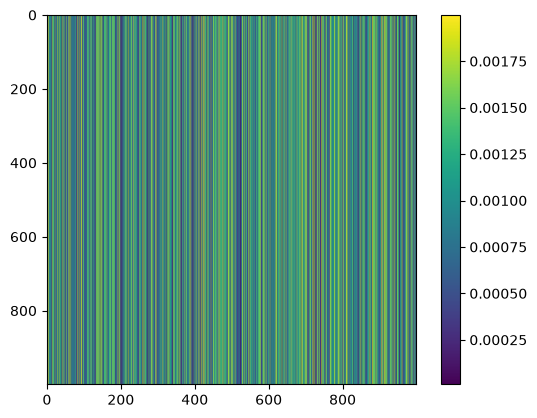

In [32]:
plt.imshow(w[0,0])
plt.colorbar()